In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install causalml networkx==3.2.1 pygraphviz dowhy econml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of dowhy to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 112.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.4/398.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.5/245.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 65.0 MB/s eta 0:00

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import causalml
from dowhy import CausalModel
import econml
import dowhy
import networkx as nx

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

from warnings import filterwarnings
filterwarnings('ignore')

## Feature Engineering Function

In [5]:

print(dowhy.__version__)
print(nx.__version__)

0.12
3.2.1


In [6]:
# Feature Engineering function
def feature_engineer_energy(df, train_stats=None, is_train=True):
    df = df.copy()

    df = df.sort_values(["building_id", "meter", "timestamp"])

    group_cols = ["building_id", "meter"]

    temp = df["air_temperature"]

    df["cooling_degree"] = np.maximum(temp - 18, 0)
    df["heating_degree"] = np.maximum(18 - temp, 0)

    df["temp_dew_gap"] = df["air_temperature"] - df["dew_temperature"]

    df["humidity_proxy"] = np.where(
        df["air_temperature"] != 0,
        df["dew_temperature"] / df["air_temperature"],
        0
    )
    df["feels_like_temp"] = df["air_temperature"] - 0.7 * df["wind_speed"]

    df["is_raining"] = (df["precip_depth_1_hr"] > 0).astype(int)

    df["weather_stress"] = (
        df["wind_speed"] +
        df["cloud_coverage"] +
        df["is_raining"]
    )

    df["storm_intensity"] = (
        df["wind_speed"] ** 2 +
        df["cloud_coverage"]
    )

    wind_dir = df["wind_direction"].fillna(0)

    df["wind_x"] = np.sin(np.deg2rad(wind_dir))
    df["wind_y"] = np.cos(np.deg2rad(wind_dir))
    df["wind_energy"] = df["wind_speed"] ** 2

    if train_stats is not None:
        pressure_mean = train_stats["pressure_mean"]
    else:
        pressure_mean = df["sea_level_pressure"].mean()

    df["pressure_anomaly"] = df["sea_level_pressure"] - pressure_mean

    df["sunlight_proxy"] = 8 - df["cloud_coverage"]

    df["thermal_load_proxy"] = (
        df["cooling_degree"] + df["heating_degree"]
    )

    df["environmental_load_index"] = (
        df["weather_stress"] + np.abs(df["pressure_anomaly"])
    )

    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.fillna(0)

    return df

## Causal Modelling

In [7]:
df = pd.read_csv("/content/drive/MyDrive/data_energy/train_data_preprocessed.csv")
df

,building_id,meter,timestamp,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,0,2016-01-01 00:00:00,0.0,0,25.0,6.0,20.0,-1.0,1019.7,0.0,0.0
1,0,0,2016-01-01 00:00:00,0.0,1,3.8,6.0,2.4,-1.0,1020.9,240.0,3.1
2,0,0,2016-01-01 00:00:00,0.0,2,15.6,6.0,-5.6,-1.0,1015.3,270.0,3.6
3,0,0,2016-01-01 00:00:00,0.0,3,10.0,8.0,2.2,-1.0,1021.1,350.0,4.1
4,0,0,2016-01-01 00:00:00,0.0,7,-1.8,6.0,-3.2,-1.0,1016.0,280.0,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...
2162819,1260,3,2016-01-03 12:00:00,350.0,11,-1.0,2.0,-1.3,11.0,1001.9,220.0,2.6
2162820,1260,3,2016-01-03 12:00:00,350.0,12,9.4,2.0,5.5,0.0,979.7,210.0,4.0
2162821,1260,3,2016-01-03 12:00:00,350.0,13,-2.8,8.0,-7.2,0.0,1023.9,340.0,5.1
2162822,1260,3,2016-01-03 12:00:00,350.0,14,-2.2,0.0,-5.0,-1.0,1011.1,190.0,1.5


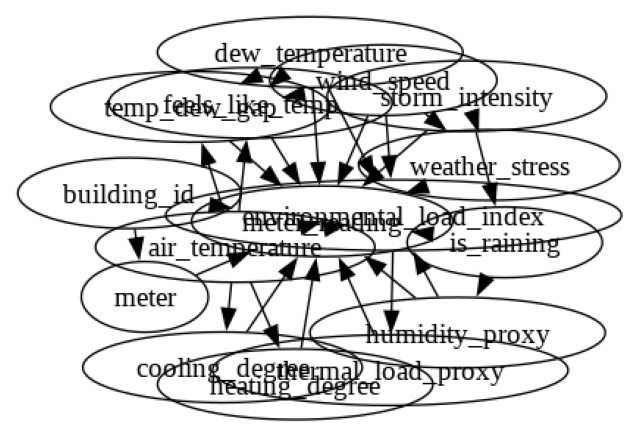

In [8]:
causal_graph = """digraph{
    building_id -> meter;
    building_id -> meter_reading;

    meter -> meter_reading;

    air_temperature -> heating_degree;
    air_temperature -> cooling_degree;
    air_temperature -> feels_like_temp;
    air_temperature -> temp_dew_gap;

    dew_temperature -> feels_like_temp;
    dew_temperature -> temp_dew_gap;

    wind_speed -> feels_like_temp;
    wind_speed -> weather_stress;

    is_raining -> humidity_proxy;
    storm_intensity -> is_raining;
    storm_intensity -> weather_stress;

    humidity_proxy -> environmental_load_index;
    air_temperature -> environmental_load_index;
    dew_temperature -> environmental_load_index;
    wind_speed -> environmental_load_index;

    environmental_load_index -> thermal_load_proxy;

    thermal_load_proxy -> meter_reading;
    heating_degree -> meter_reading;
    cooling_degree -> meter_reading;
    temp_dew_gap -> meter_reading;
    feels_like_temp -> meter_reading;
    humidity_proxy -> meter_reading;
    weather_stress -> meter_reading;
    is_raining -> meter_reading;
    storm_intensity -> meter_reading;

    air_temperature -> meter_reading;
    dew_temperature -> meter_reading;
    wind_speed -> meter_reading;
}"""

causal_model = CausalModel(
    data=df,
    treatment='meter',
    outcome='meter_reading',
    graph=causal_graph
)

causal_model.view_model()

In [11]:
estimand = causal_model.identify_effect()

causal_estimate = causal_model.estimate_effect(
    estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
    target_units="ate"
)

print(causal_estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d                                  
────────(E[meter_reading|building_id])
d[meter]                              
Estimand assumption 1, Unconfoundedness: If U→{meter} and U→meter_reading then P(meter_reading|meter,building_id,U) = P(meter_reading|meter,building_id)

## Realized estimand
b: meter_reading~meter+building_id+meter*dew_temperature+meter*air_temperature+meter*wind_speed
Target units: 

## Estimate
Mean value: 1377.446189883373
### Conditional Estimates
__categorical__dew_temperature  __categorical__air_temperature  __categorical__wind_speed
(-20.001, -6.7]                 (-16.701, -2.0]                 (-0.001, 2.1]                1281.715395
                                                                (2.1, 3.1]                   1330.040262
                                                                (3.1, 4

In [15]:
random_cause = causal_model.refute_estimate(
    estimand,
    causal_estimate,
    method_name="random_common_cause"
)

placebo = causal_model.refute_estimate(
    estimand,
    causal_estimate,
    method_name="placebo_treatment_refuter"
)

refutation = causal_model.refute_estimate(
    estimand,
    causal_estimate,
    method_name="data_subset_refuter"
)

print(f"Random Cause: {random_cause}")
print(f"Placebo: {placebo}")
print(f"Refutation: {refutation}")

Random Cause: Refute: Add a random common cause
Estimated effect:1377.446189883373
New effect:1377.4478762881977
p value:0.94

Placebo: Refute: Use a Placebo Treatment
Estimated effect:1377.446189883373
New effect:3.248346628734433
p value:0.8999999999999999

Refutation: Refute: Use a subset of data
Estimated effect:1377.446189883373
New effect:1377.175458059748
p value:1.0



In [16]:
import joblib

joblib.dump(
    causal_estimate.estimator,
    "causal_estimator.pkl"
)

['causal_estimator.pkl']